# First MASA Experiment

This notebook gets a first MASA run working end to end. We will preview the Bridge Crossing environment, wrap it with MASA's labelled PCTL constraint stack, step it by hand, and run a tiny Q-learning smoke experiment.

The matching static docs page is at `docs/Tutorials/Basics/First MASA Experiment.md`.

## CPU-first setup

Set these before importing MASA/JAX modules. They keep the tutorial quiet and portable on machines that have GPU packages installed but should run this example on CPU.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

SEED = 0
ACTION_NAMES = {
    0: "left",
    1: "right",
    2: "down",
    3: "up",
    4: "stay",
}


## Preview Bridge Crossing

`bridge_crossing` is a tabular gridworld. The agent starts at the lower-left corner, receives reward for reaching a goal row, and incurs safety cost when it reaches lava.

{'reset_obs': 380, 'reset_info': {}}


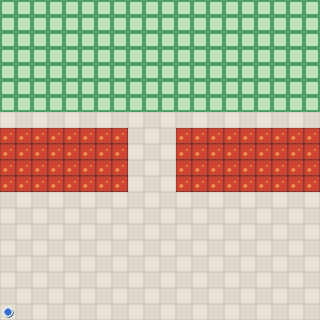

In [2]:
from IPython.display import display
from PIL import Image

from masa.envs.tabular.bridge_crossing import BridgeCrossing

preview_env = BridgeCrossing(render_mode="rgb_array", render_window_size=320)
obs, info = preview_env.reset(seed=SEED)
print({"reset_obs": obs, "reset_info": info})
display(Image.fromarray(preview_env.render()))
preview_env.close()


## Build a MASA environment

`make_env` applies MASA's standard wrapper stack. Here we use the PCTL-style probabilistic safety constraint with the environment's default `label_fn` and `cost_fn`.

In [3]:
from pprint import pprint

import masa
from masa.common.utils import make_env
from masa.envs.tabular.bridge_crossing import cost_fn, label_fn

def build_masa_env():
    return make_env(
        "BridgeCrossing",
        "PCTL",
        400,
        label_fn=label_fn,
        constraint_kwargs={"cost_fn": cost_fn, "alpha": 0.01},
    )

env = build_masa_env()
obs, info = env.reset(seed=SEED)

print("reset observation:", obs)
print("info[\"labels\"]:", info["labels"])
print("info[\"constraint\"]:")
pprint(info["constraint"])


reset observation: 380
info["labels"]: {'start'}
info["constraint"]:
{'step': {'cost': 0.0, 'violation': 0.0}, 'type': 'pctl'}


## Step the environment by hand

The observation and reward still follow Gymnasium. MASA adds semantic safety information through `info["labels"]` and `info["constraint"]`.

In [4]:
scripted_actions = [3, 3, 3, 4, 1]
rows = []

for step, action in enumerate(scripted_actions, start=1):
    obs, reward, terminated, truncated, info = env.step(action)
    rows.append(
        {
            "step": step,
            "action": ACTION_NAMES[action],
            "obs": int(obs),
            "reward": float(reward),
            "terminated": bool(terminated),
            "truncated": bool(truncated),
            "labels": sorted(info["labels"]),
            "constraint_step": info["constraint"]["step"],
        }
    )
    if terminated or truncated:
        break

pprint(rows)
env.close()


[{'action': 'up',
  'constraint_step': {'cost': 0.0, 'violation': 0.0},
  'labels': [],
  'obs': 360,
  'reward': 0.0,
  'step': 1,
  'terminated': False,
  'truncated': False},
 {'action': 'up',
  'constraint_step': {'cost': 0.0, 'violation': 0.0},
  'labels': [],
  'obs': 340,
  'reward': 0.0,
  'step': 2,
  'terminated': False,
  'truncated': False},
 {'action': 'up',
  'constraint_step': {'cost': 0.0, 'violation': 0.0},
  'labels': [],
  'obs': 320,
  'reward': 0.0,
  'step': 3,
  'terminated': False,
  'truncated': False},
 {'action': 'stay',
  'constraint_step': {'cost': 0.0, 'violation': 0.0},
  'labels': [],
  'obs': 320,
  'reward': 0.0,
  'step': 4,
  'terminated': False,
  'truncated': False},
 {'action': 'right',
  'constraint_step': {'cost': 0.0, 'violation': 0.0},
  'labels': [],
  'obs': 321,
  'reward': 0.0,
  'step': 5,
  'terminated': False,
  'truncated': False}]


## Run a tiny Q-learning experiment

This is intentionally small. It is not meant to learn a strong policy; it is meant to prove the environment, constraint, algorithm, evaluation, and logger all connect correctly. The command-line equivalent uses `--algo q_learning`; the Python API uses the `QL` class directly.

In [5]:
from masa.algorithms.tabular import QL

train_env = build_masa_env()
eval_env = build_masa_env()

algo = QL(
    train_env,
    tensorboard_logdir=None,
    seed=SEED,
    monitor=True,
    device="cpu",
    verbose=0,
    env_fn=build_masa_env,
    eval_env=eval_env,
)

algo.train(
    num_frames=20,
    eval_freq=10,
    log_freq=10,
    num_eval_episodes=1,
    stats_window_size=10,
)

train_env.close()
eval_env.close()


I0000 00:00:1779205640.100058  102364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779205642.888416  102364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


frames:   0%|                                                                                    | 0/20 [00:00…

evaluation:   0%|                                                                                 | 0/1 [00:00…

-----------------------------------
|  run/               |           |
|    fps              |  230.2    |
|    time_elapsed     |  0.04344  |
|    total_timesteps  |  10       |
-----------------------------------
|  train/rollout/     |           |
|    cum_unsafe       |  0        |
|    satisfied        |  1        |
-----------------------------------
|  train/stats/       |           |
|    alpha            |  0.1      |
|    temp             |  0.05     |
-----------------------------------



evaluation:   0%|                                                                                 | 0/1 [00:00…

----------------------------------
|  run/               |          |
|    fps              |  188.6   |
|    time_elapsed     |  0.1061  |
|    total_timesteps  |  20      |
----------------------------------
|  train/rollout/     |          |
|    cum_unsafe       |  0       |
|    satisfied        |  1       |
----------------------------------
|  train/stats/       |          |
|    alpha            |  0.1     |
|    temp             |  0.05    |
----------------------------------
|  eval/rollout/      |          |
|    cum_unsafe       |  1       |
|    satisfied        |  0       |
|    ep_reward        |  0       |
|    ep_length        |  142     |
----------------------------------



## Read the logs

- `train/rollout` contains episode-level constraint metrics collected during training, such as cumulative unsafe events and whether the constraint was satisfied.
- `train/stats` contains algorithm statistics, such as the Q-learning step size and exploration temperature.
- `eval/rollout` appears after evaluation runs and reports the same kind of episode metrics for the evaluation environment, plus reward and episode length.

For a real experiment, increase `num_frames`, run multiple seeds, and keep the short smoke configuration as a quick correctness check.